In [95]:
import pandas as pd
import re
with open('b3.txt', 'r', encoding='utf-8') as f:
    data = f.read()
pattern = r'(\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}(?:\s?[APMapm]{2})?)\s-\s(.*?):\s(.*)'
matches = re.findall(pattern, data)
dates = []
users = []
messages = []
for match in matches:    
    dates.append(match[0])
    users.append(match[1])
    messages.append(match[2])
df = pd.DataFrame({
    'datetime': dates,
    'user': users,
    'message': messages
})

df['datetime'] = (
    df['datetime']
    .str.replace('\u202f', ' ', regex=False)
    .str.strip()
)

df['datetime'] = pd.to_datetime(
    df['datetime'],
    format='mixed'
)
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day

df['hour'] = df['datetime'].dt.hour
df['minute'] = df['datetime'].dt.minute

df['month_name'] = df['datetime'].dt.month_name()
df['day_name'] = df['datetime'].dt.day_name()

df['date'] = df['datetime'].dt.date
df['time'] = df['datetime'].dt.time

df.head()

,datetime,user,message,year,month,day,hour,minute,month_name,day_name,date,time
0,2026-03-03 12:59:00,+91 93724 97101,Asjad bol rha tha ki ML mai kuch kam kiye mam ...,2026,3,3,12,59,March,Tuesday,2026-03-03,12:59:00
1,2026-03-03 14:14:00,+91 90822 60261,Kuch kam nhi kiye hai mai mam ke pass gya tha ...,2026,3,3,14,14,March,Tuesday,2026-03-03,14:14:00
2,2026-03-03 14:14:00,+91 75067 11416,Bol pir kya kya phadna hai,2026,3,3,14,14,March,Tuesday,2026-03-03,14:14:00
3,2026-03-03 14:25:00,+91 90280 34761,Qb hai kya ml ki?,2026,3,3,14,25,March,Tuesday,2026-03-03,14:25:00
4,2026-03-03 14:30:00,+91 70219 05795,,2026,3,3,14,30,March,Tuesday,2026-03-03,14:30:00


In [96]:
# active users
print((df['user'].value_counts().head(5)/df.shape[0])*100)

user
Shaikh Salahuddin    15.911562
+91 91754 16601      11.888365
+91 80976 26564       8.843784
+91 88285 35549       7.611453
+91 93724 97101       7.502718
Name: count, dtype: float64


(array([20513., 20527., 20544., 20558., 20574., 20588.]),
 [Text(20513.0, 0, '2026-03-01'),
  Text(20527.0, 0, '2026-03-15'),
  Text(20544.0, 0, '2026-04-01'),
  Text(20558.0, 0, '2026-04-15'),
  Text(20574.0, 0, '2026-05-01'),
  Text(20588.0, 0, '2026-05-15')])

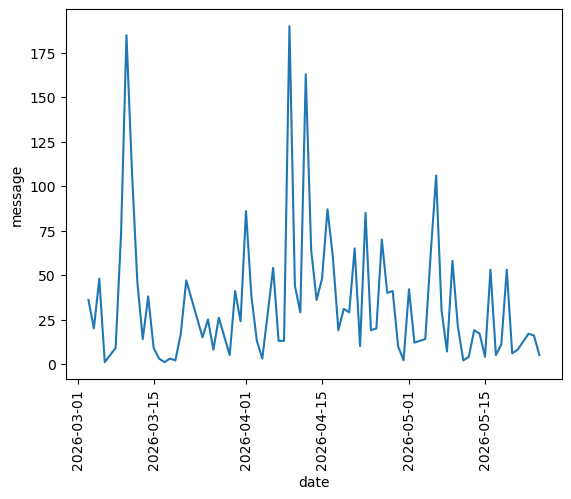

In [97]:
# timeline analysis
import seaborn as sns
import matplotlib.pyplot as plt

daily = df.groupby('date').count()['message']
sns.lineplot(data=daily)
plt.xticks(rotation='vertical')


In [98]:
monthly_timeline = df.groupby(
    ['year', 'month_name']
).count()['message'].reset_index()

<Axes: xlabel='month_name', ylabel='message'>

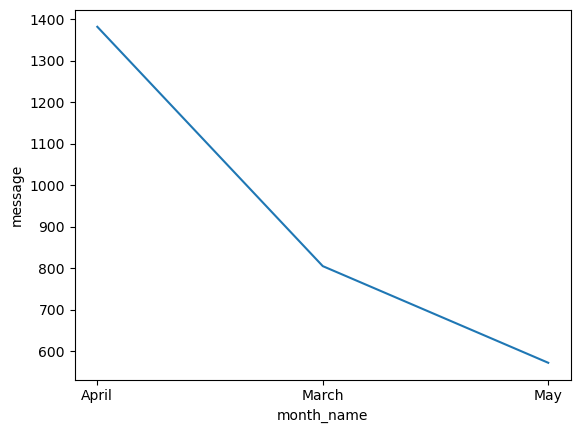

In [99]:
sns.lineplot(data=monthly_timeline,x='month_name',y='message')

In [100]:
pivot = df.pivot_table(
    index='day_name',
    columns='hour',
    values='message',
    aggfunc='count'
)
pivot

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_name,,,,,,,,,,,,,,,,,,,,,
Friday,25.0,10.0,1.0,4.0,NaN,1.0,1.0,14.0,20.0,10.0,...,19.0,12.0,5.0,10.0,NaN,30.0,12.0,10.0,2.0,13.0
Monday,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,7.0,...,18.0,21.0,4.0,NaN,7.0,86.0,52.0,30.0,26.0,32.0
Saturday,12.0,5.0,1.0,NaN,NaN,NaN,8.0,NaN,12.0,8.0,...,60.0,22.0,2.0,26.0,1.0,9.0,2.0,27.0,6.0,4.0
Sunday,6.0,6.0,7.0,NaN,1.0,4.0,NaN,NaN,3.0,NaN,...,NaN,2.0,4.0,14.0,20.0,136.0,32.0,10.0,31.0,22.0
Thursday,12.0,5.0,4.0,NaN,NaN,3.0,NaN,NaN,7.0,17.0,...,15.0,9.0,16.0,23.0,20.0,88.0,40.0,73.0,128.0,55.0
Tuesday,8.0,NaN,NaN,NaN,NaN,NaN,20.0,17.0,14.0,22.0,...,18.0,69.0,17.0,20.0,23.0,90.0,71.0,45.0,5.0,42.0
Wednesday,15.0,2.0,NaN,NaN,NaN,NaN,2.0,2.0,NaN,1.0,...,16.0,18.0,15.0,36.0,59.0,5.0,69.0,24.0,82.0,49.0


In [101]:
days = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

pivot = pivot.reindex(days)

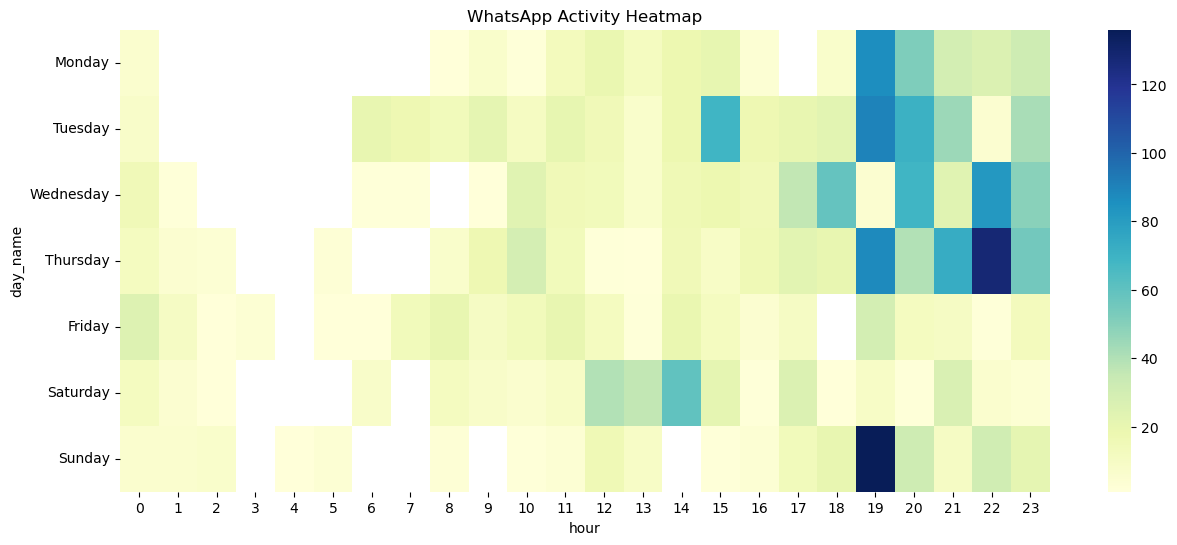

In [102]:
plt.figure(figsize=(15,6))

sns.heatmap(
    pivot,
    cmap='YlGnBu'
)

plt.title("WhatsApp Activity Heatmap")

plt.show()

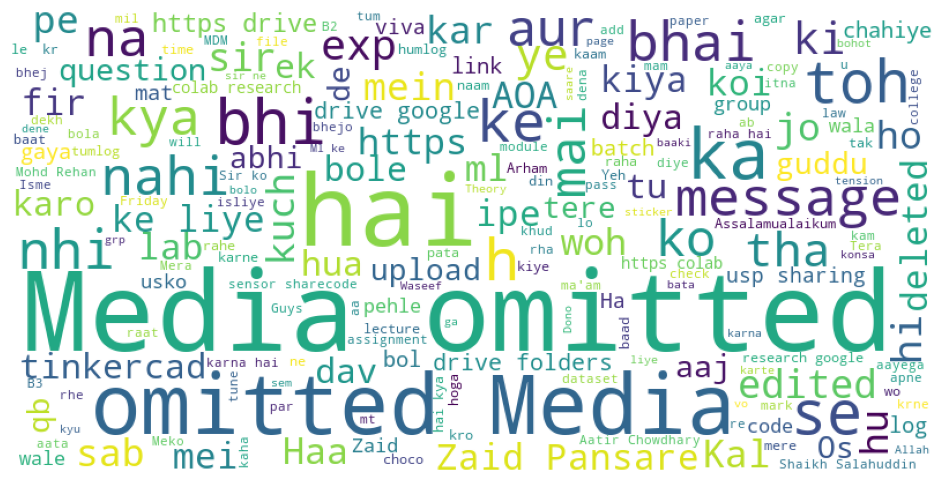

In [103]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all messages into one string
text = " ".join(df['message'])

# Create WordCloud object
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    min_font_size=10
)

# Generate word cloud
wordcloud = wc.generate(text)

# Plot
plt.figure(figsize=(15,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [104]:
import emoji

emojis = []

for msg in df['message']:
    
    for c in msg:
        
        if c in emoji.EMOJI_DATA:
            emojis.append(c)
from collections import Counter

Counter(emojis).most_common(10)

[('😭', 41),
 ('😂', 18),
 ('💔', 15),
 ('🤧', 13),
 ('🫂', 11),
 ('🏻', 10),
 ('🤣', 8),
 ('✨', 8),
 ('😔', 6),
 ('📈', 6)]

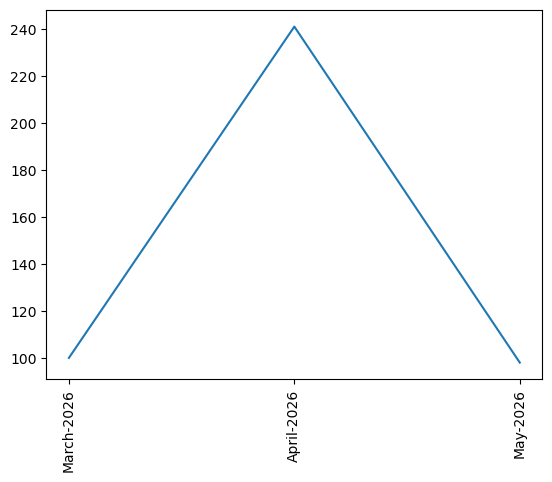

In [106]:
selected_user = 'Shaikh Salahuddin'

user_df = df[df['user'] == selected_user]
monthly_timeline = user_df.groupby(
    ['year','month','month_name']
).count()['message'].reset_index()

monthly_timeline['time'] = (
    monthly_timeline['month_name']
    + "-"
    + monthly_timeline['year'].astype(str)
)
import matplotlib.pyplot as plt

plt.plot(
    monthly_timeline['time'],
    monthly_timeline['message']
)

plt.xticks(rotation='vertical')

plt.show()

In [107]:
pivot = user_df.pivot_table(
    index='day_name',
    columns='hour',
    values='message',
    aggfunc='count'
)

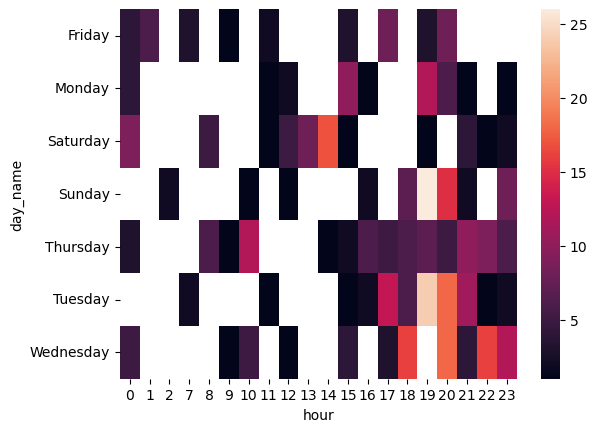

In [108]:
import seaborn as sns

sns.heatmap(pivot)

plt.show()

In [109]:
words = []

for message in user_df['message']:
    words.extend(message.split())

from collections import Counter

Counter(words).most_common(20)

[('hai', 76),
 ('<Media', 67),
 ('omitted>', 67),
 ('ke', 41),
 ('nhi', 39),
 ('toh', 30),
 ('mein', 24),
 ('aur', 24),
 ('ka', 24),
 ('message', 23),
 ('se', 20),
 ('@\u2068~Zaid', 18),
 ('Pansare\u2069', 18),
 ('bhi', 17),
 ('<This', 17),
 ('was', 17),
 ('edited>', 17),
 ('ko', 16),
 ('Haa', 15),
 ('2', 14)]